# CMU-MOSI — Processed Feature EDA: Aligned vs Unaligned

This notebook analyzes the **existing processed feature files** for CMU-MOSI.

### Goals
- Inspect the actual processed dataset structure, dimensions and splits.
- Compare **aligned vs unaligned** representations where both exist.
- Study sentiment distribution and sequence structure.
- Compare modality statistics, feature energy, zero/padding behaviour and modality relationships.
- Produce plots that lead to **clear, defensible observations**.
- Save figures and tables to the project deliverables folder.

> **Important:** This notebook does not extract raw text/audio/video. It uses only the processed files already present in `MyDrive/CMU-MOSI/Processed`.


In [1]:
# ============================================================
# 1. SETUP
# ============================================================
import os
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

from google.colab import drive
drive.mount("/content/drive")

MYDRIVE = Path("/content/drive/MyDrive")
DATA_DIR = MYDRIVE / "CMU-MOSI" / "Processed"
OUTPUT_DIR = MYDRIVE / "mplmm_final_deliverables" / "outputs" / "CMU-MOSI"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Processed folder:", DATA_DIR)
print("Output folder:", OUTPUT_DIR)


Mounted at /content/drive
Processed folder: /content/drive/MyDrive/CMU-MOSI/Processed
Output folder: /content/drive/MyDrive/mplmm_final_deliverables/outputs/CMU-MOSI


In [2]:
# ============================================================
# 2. DISCOVER PROCESSED FILES
# ============================================================
def find_processed_files(folder):
    valid = {".pkl", ".pickle", ".npz", ".npy"}
    return sorted(p for p in folder.rglob("*")
                  if p.is_file() and p.suffix.lower() in valid)

files = find_processed_files(DATA_DIR)
print(f"Found {len(files)} processed candidate files.\n")
for p in files:
    print(" -", p.relative_to(DATA_DIR))

def alignment_hint(path):
    n = path.name.lower()
    if any(k in n for k in ["unalign", "noalign", "unaligned"]):
        return "unaligned"
    if any(k in n for k in ["align", "aligned"]):
        return "aligned"
    return "unknown"

file_table = pd.DataFrame({
    "file": [str(p.relative_to(DATA_DIR)) for p in files],
    "alignment_hint": [alignment_hint(p) for p in files]
})
display(file_table)


Found 2 processed candidate files.

 - aligned_50.pkl
 - unaligned_50.pkl


,file,alignment_hint
0,aligned_50.pkl,aligned
1,unaligned_50.pkl,unaligned


In [3]:
# ============================================================
# 3. SELECT ALIGNED AND UNALIGNED FILES
# ============================================================
# Selection is based only on files that actually exist in:
# MyDrive/CMU-MOSI/Processed

aligned_candidates = [p for p in files if alignment_hint(p) == "aligned"]
unaligned_candidates = [p for p in files if alignment_hint(p) == "unaligned"]

def choose_best(candidates):
    if not candidates:
        return None
    keywords = ["cmumosi", "cmu-mosi", "senti_data", "data"]
    ranked = sorted(
        candidates,
        key=lambda p: (-sum(k in p.name.lower().replace("-", "") for k in keywords),
                       len(p.name))
    )
    return ranked[0]

ALIGNED_PATH = choose_best(aligned_candidates)
UNALIGNED_PATH = choose_best(unaligned_candidates)

print("ALIGNED_PATH  :", ALIGNED_PATH)
print("UNALIGNED_PATH:", UNALIGNED_PATH)

if ALIGNED_PATH is None or UNALIGNED_PATH is None:
    print("\nWARNING: Both variants were not automatically found.")
    print("The notebook will still analyze whichever variants exist.")
    print("If your filenames use unusual names, set ALIGNED_PATH and/or")
    print("UNALIGNED_PATH manually after inspecting the table above.")


ALIGNED_PATH  : /content/drive/MyDrive/CMU-MOSI/Processed/aligned_50.pkl
UNALIGNED_PATH: /content/drive/MyDrive/CMU-MOSI/Processed/unaligned_50.pkl


In [4]:
# ============================================================
# 4. LOAD PROCESSED DATA
# ============================================================
def load_file(path):
    if path is None:
        return None
    path = Path(path)
    if path.suffix.lower() in {".pkl", ".pickle"}:
        with open(path, "rb") as f:
            return pickle.load(f)
    if path.suffix.lower() == ".npz":
        z = np.load(path, allow_pickle=True)
        return {k: z[k] for k in z.files}
    if path.suffix.lower() == ".npy":
        return np.load(path, allow_pickle=True).item()
    raise ValueError(f"Unsupported file: {path}")

aligned = load_file(ALIGNED_PATH)
unaligned = load_file(UNALIGNED_PATH)

datasets = {}
if aligned is not None:
    datasets["Aligned"] = aligned
if unaligned is not None:
    datasets["Unaligned"] = unaligned

print("Loaded variants:", list(datasets))


Loaded variants: ['Aligned', 'Unaligned']


In [5]:
# ============================================================
# 5. ROBUST INSPECTION HELPERS
# ============================================================
MODALITIES = ["text", "audio", "vision"]
SPLITS = ["train", "valid", "val", "test"]

def get_split(data, split):
    if not isinstance(data, dict):
        return None
    if split in data and isinstance(data[split], dict):
        return data[split]
    return None

def find_label_key(split):
    if split is None:
        return None
    for k in ["regression_labels", "labels", "label", "sentiment"]:
        if k in split:
            return k
    return None

def describe_variant(data, name):
    print("="*72)
    print(name.upper())
    print("="*72)
    print("Top-level type:", type(data).__name__)
    if isinstance(data, dict):
        print("Top-level keys:", list(data.keys()))
        for split in SPLITS:
            s = get_split(data, split)
            if s is None:
                continue
            print(f"\n{split.upper()} keys:", list(s.keys()))
            for k in ["text","audio","vision","labels","regression_labels"]:
                if k in s:
                    print(f"  {k:18s} shape={np.asarray(s[k]).shape}")

for name, data in datasets.items():
    describe_variant(data, name)


ALIGNED
Top-level type: dict
Top-level keys: ['train', 'valid', 'test']

TRAIN keys: ['raw_text', 'audio', 'vision', 'id', 'text', 'text_bert', 'annotations', 'classification_labels', 'regression_labels']
  text               shape=(1284, 50, 768)
  audio              shape=(1284, 50, 5)
  vision             shape=(1284, 50, 20)
  regression_labels  shape=(1284,)

VALID keys: ['raw_text', 'audio', 'vision', 'id', 'text', 'text_bert', 'annotations', 'classification_labels', 'regression_labels']
  text               shape=(229, 50, 768)
  audio              shape=(229, 50, 5)
  vision             shape=(229, 50, 20)
  regression_labels  shape=(229,)

TEST keys: ['raw_text', 'audio', 'vision', 'id', 'text', 'text_bert', 'annotations', 'classification_labels', 'regression_labels']
  text               shape=(686, 50, 768)
  audio              shape=(686, 50, 5)
  vision             shape=(686, 50, 20)
  regression_labels  shape=(686,)
UNALIGNED
Top-level type: dict
Top-level keys: ['train'

In [6]:
# ============================================================
# 6. DIMENSIONS / SPLIT SUMMARY
# ============================================================
rows = []
for variant, data in datasets.items():
    for split in SPLITS:
        s = get_split(data, split)
        if s is None:
            continue
        row = {"variant": variant, "split": split}
        for k in ["text","audio","vision"]:
            if k in s:
                a = np.asarray(s[k])
                row[f"{k}_shape"] = str(a.shape)
                row[f"{k}_samples"] = a.shape[0] if a.ndim else np.nan
                row[f"{k}_seq_len"] = a.shape[1] if a.ndim >= 2 else np.nan
                row[f"{k}_dim"] = a.shape[-1] if a.ndim >= 2 else np.nan
        lk = find_label_key(s)
        if lk:
            row["label_key"] = lk
            row["label_samples"] = len(np.asarray(s[lk]).reshape(-1))
        rows.append(row)

dims_df = pd.DataFrame(rows)
display(dims_df)
dims_df.to_csv(TABLE_DIR / "dimensions_and_splits.csv", index=False)


,variant,split,text_shape,text_samples,text_seq_len,text_dim,audio_shape,audio_samples,audio_seq_len,audio_dim,vision_shape,vision_samples,vision_seq_len,vision_dim,label_key,label_samples
0,Aligned,train,"(1284, 50, 768)",1284,50,768,"(1284, 50, 5)",1284,50,5,"(1284, 50, 20)",1284,50,20,regression_labels,1284
1,Aligned,valid,"(229, 50, 768)",229,50,768,"(229, 50, 5)",229,50,5,"(229, 50, 20)",229,50,20,regression_labels,229
2,Aligned,test,"(686, 50, 768)",686,50,768,"(686, 50, 5)",686,50,5,"(686, 50, 20)",686,50,20,regression_labels,686
3,Unaligned,train,"(1284, 50, 768)",1284,50,768,"(1284, 375, 5)",1284,375,5,"(1284, 500, 20)",1284,500,20,regression_labels,1284
4,Unaligned,valid,"(229, 50, 768)",229,50,768,"(229, 375, 5)",229,375,5,"(229, 500, 20)",229,500,20,regression_labels,229
5,Unaligned,test,"(686, 50, 768)",686,50,768,"(686, 375, 5)",686,375,5,"(686, 500, 20)",686,500,20,regression_labels,686


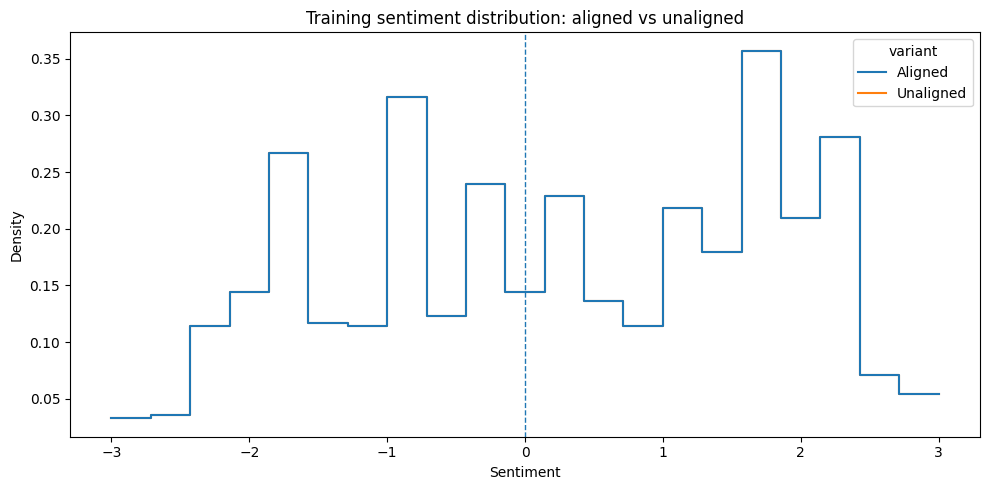

,variant,samples,mean,std,median,min,max
0,Aligned,1284,0.2345,1.5100,0.2000,-3.0000,3.0000
1,Unaligned,1284,0.2345,1.5100,0.2000,-3.0000,3.0000


In [7]:
# ============================================================
# 7. SENTIMENT DISTRIBUTION — ALIGNED VS UNALIGNED
# ============================================================
label_rows = []

for variant, data in datasets.items():
    s = get_split(data, "train")
    if s is None:
        continue
    lk = find_label_key(s)
    if lk is None:
        continue
    y = np.asarray(s[lk], dtype=float).reshape(-1)
    label_rows.append(pd.DataFrame({"variant": variant, "sentiment": y}))

labels_df = pd.concat(label_rows, ignore_index=True) if label_rows else pd.DataFrame()

if not labels_df.empty:
    plt.figure(figsize=(10,5))
    sns.histplot(data=labels_df, x="sentiment", hue="variant",
                 bins=21, stat="density", common_norm=False,
                 element="step", fill=False)
    plt.axvline(0, ls="--", lw=1)
    plt.title("Training sentiment distribution: aligned vs unaligned")
    plt.xlabel("Sentiment")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "01_sentiment_aligned_vs_unaligned.png", dpi=180, bbox_inches="tight")
    plt.show()

    summary = labels_df.groupby("variant")["sentiment"].agg(
        samples="size", mean="mean", std="std", median="median",
        min="min", max="max"
    ).reset_index()
    display(summary)
    summary.to_csv(TABLE_DIR / "sentiment_summary.csv", index=False)


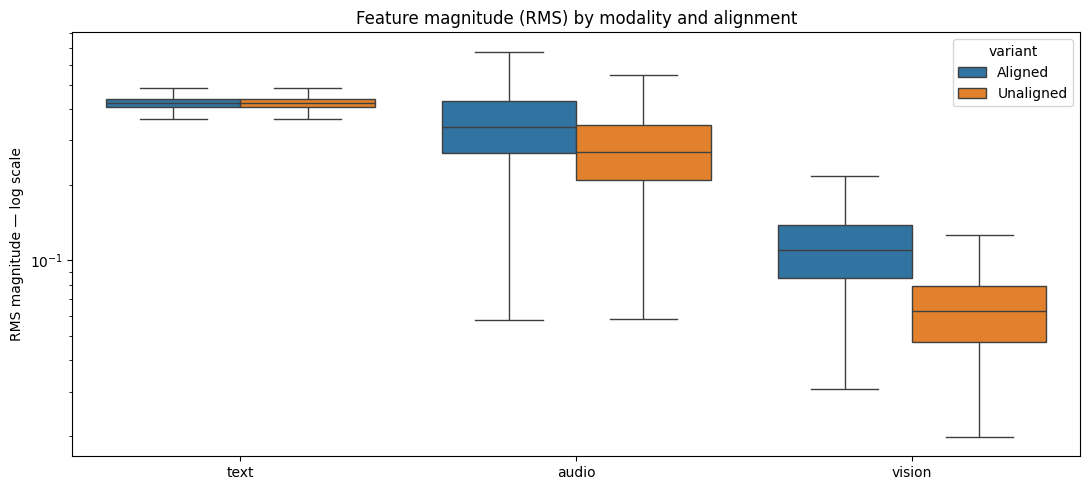

,variant,modality,mean,median,std,q25,q75
0,Aligned,audio,0.3597,0.3407,0.1352,0.2676,0.4327
1,Aligned,text,0.4256,0.4220,0.0265,0.4075,0.4385
2,Aligned,vision,0.1157,0.1094,0.0426,0.0851,0.1380
3,Unaligned,audio,0.2850,0.2701,0.1061,0.2079,0.3452
4,Unaligned,text,0.4256,0.4220,0.0265,0.4075,0.4385
5,Unaligned,vision,0.0666,0.0628,0.0264,0.0475,0.0790


In [9]:
# ============================================================
# 9. MODALITY FEATURE ENERGY / MAGNITUDE
# ============================================================
energy_rows = []
for variant, data in datasets.items():
    s = get_split(data, "train")
    if s is None:
        continue
    for mod in MODALITIES:
        if mod not in s:
            continue
        a = np.asarray(s[mod], dtype=np.float32)
        if a.dtype == object:
            vals = np.array([np.sqrt(np.mean(np.asarray(x, dtype=float)**2)) for x in a])
        elif a.ndim >= 2:
            vals = np.sqrt(np.mean(a.reshape(a.shape[0], -1)**2, axis=1))
        else:
            vals = np.abs(a)
        for v in vals:
            energy_rows.append({"variant":variant, "modality":mod, "rms":float(v)})

energy_df = pd.DataFrame(energy_rows)

if not energy_df.empty:
    plt.figure(figsize=(11,5))
    sns.boxplot(data=energy_df, x="modality", y="rms", hue="variant", showfliers=False)
    plt.yscale("log")
    plt.title("Feature magnitude (RMS) by modality and alignment")
    plt.xlabel("")
    plt.ylabel("RMS magnitude — log scale")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "03_modality_rms_aligned_vs_unaligned.png", dpi=180, bbox_inches="tight")
    plt.show()

    energy_summary = energy_df.groupby(["variant","modality"])["rms"].agg(
        mean="mean", median="median", std="std",
        q25=lambda x: x.quantile(.25), q75=lambda x: x.quantile(.75)
    ).reset_index()
    display(energy_summary)
    energy_summary.to_csv(TABLE_DIR / "modality_rms_summary.csv", index=False)


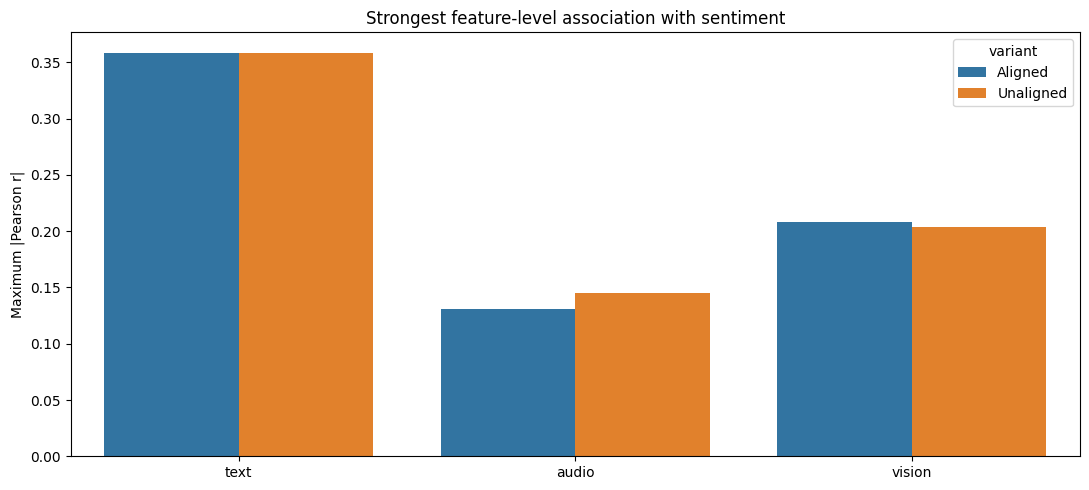

,variant,modality,max_abs_feature_corr,median_abs_feature_corr
0,Aligned,text,0.3588,0.0877
1,Aligned,audio,0.1305,0.0724
2,Aligned,vision,0.2082,0.0581
3,Unaligned,text,0.3588,0.0877
4,Unaligned,audio,0.1454,0.0749
5,Unaligned,vision,0.2042,0.0727


In [11]:
# ============================================================
# 11. MODALITY–SENTIMENT ASSOCIATION
# ============================================================
corr_rows = []

for variant, data in datasets.items():
    s = get_split(data, "train")
    if s is None:
        continue
    lk = find_label_key(s)
    if lk is None:
        continue
    y = np.asarray(s[lk], dtype=float).reshape(-1)

    for mod in MODALITIES:
        if mod not in s:
            continue
        a = np.asarray(s[mod], dtype=float)
        if a.ndim != 3 or a.shape[0] != len(y):
            continue
        x = np.nanmean(a, axis=1)
        corrs = []
        for j in range(x.shape[1]):
            if np.std(x[:,j]) > 0:
                corrs.append(np.corrcoef(x[:,j], y)[0,1])
        if corrs:
            corr_rows.append({
                "variant":variant,
                "modality":mod,
                "max_abs_feature_corr":float(np.max(np.abs(corrs))),
                "median_abs_feature_corr":float(np.median(np.abs(corrs)))
            })

corr_df = pd.DataFrame(corr_rows)

if not corr_df.empty:
    plt.figure(figsize=(11,5))
    sns.barplot(data=corr_df, x="modality", y="max_abs_feature_corr", hue="variant")
    plt.title("Strongest feature-level association with sentiment")
    plt.xlabel("")
    plt.ylabel("Maximum |Pearson r|")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "05_modality_sentiment_association.png", dpi=180, bbox_inches="tight")
    plt.show()
    display(corr_df)
    corr_df.to_csv(TABLE_DIR / "modality_sentiment_correlation.csv", index=False)


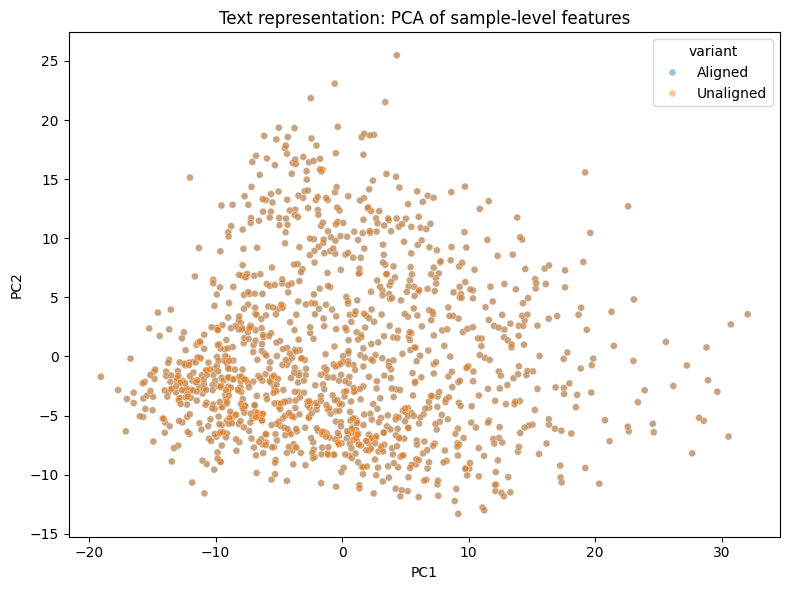

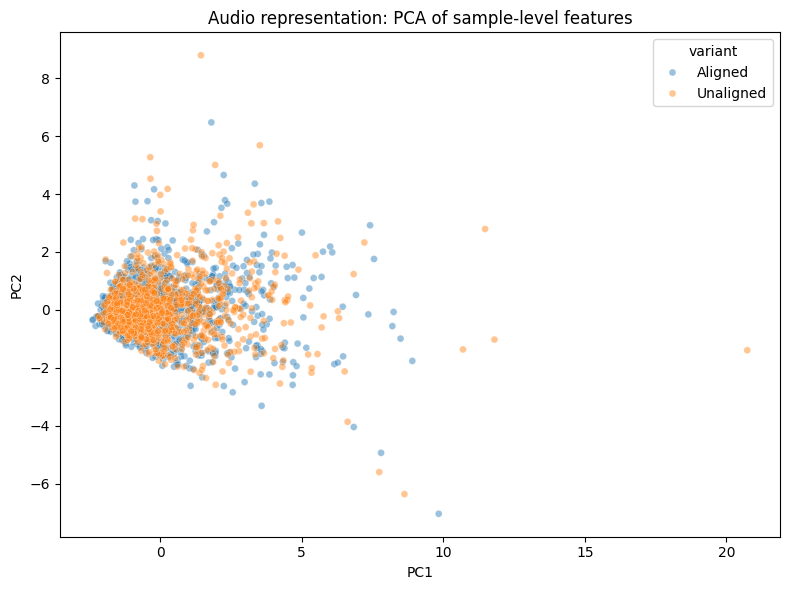

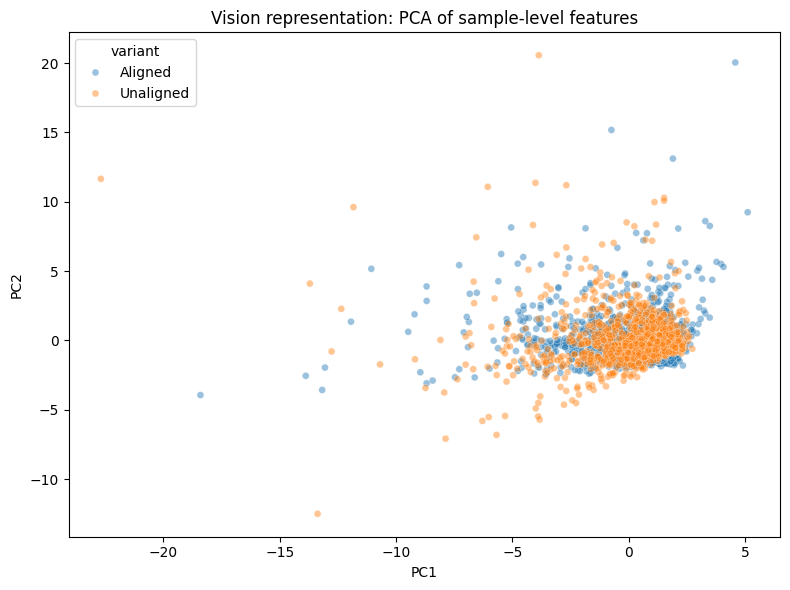

In [12]:
# ============================================================
# 12. PCA — MODALITY REPRESENTATION STRUCTURE
# ============================================================
pca_rows = []

for variant, data in datasets.items():
    s = get_split(data, "train")
    if s is None:
        continue
    for mod in MODALITIES:
        if mod not in s:
            continue
        a = np.asarray(s[mod], dtype=float)
        if a.ndim != 3 or a.shape[0] < 3:
            continue
        X = np.nanmean(a, axis=1)
        n = min(len(X), 1200)
        rng = np.random.default_rng(42)
        idx = rng.choice(len(X), n, replace=False)
        Xs = StandardScaler().fit_transform(X[idx])
        Z = PCA(n_components=2, random_state=42).fit_transform(Xs)
        tmp = pd.DataFrame({"PC1":Z[:,0], "PC2":Z[:,1],
                            "variant":variant, "modality":mod})
        pca_rows.append(tmp)

if pca_rows:
    pca_df = pd.concat(pca_rows, ignore_index=True)
    for mod in pca_df["modality"].unique():
        plt.figure(figsize=(8,6))
        sns.scatterplot(data=pca_df[pca_df.modality==mod],
                        x="PC1", y="PC2", hue="variant",
                        alpha=.45, s=25)
        plt.title(f"{mod.title()} representation: PCA of sample-level features")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"06_pca_{mod}.png", dpi=180, bbox_inches="tight")
        plt.show()


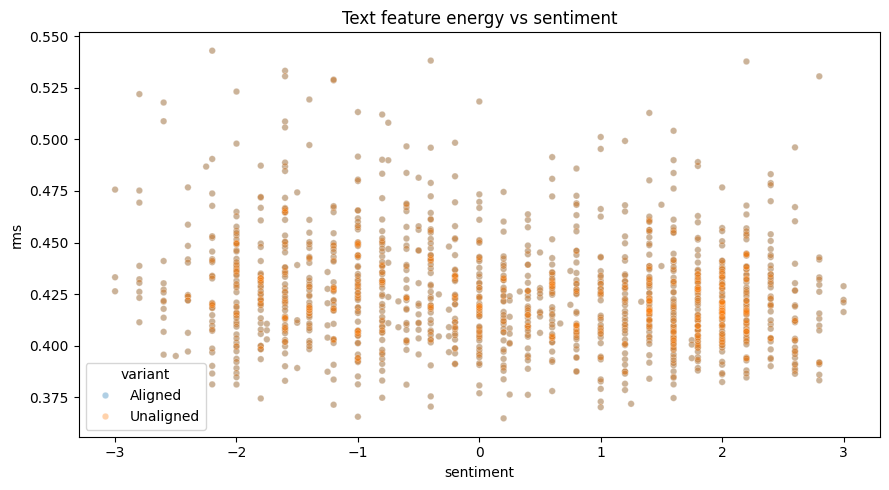

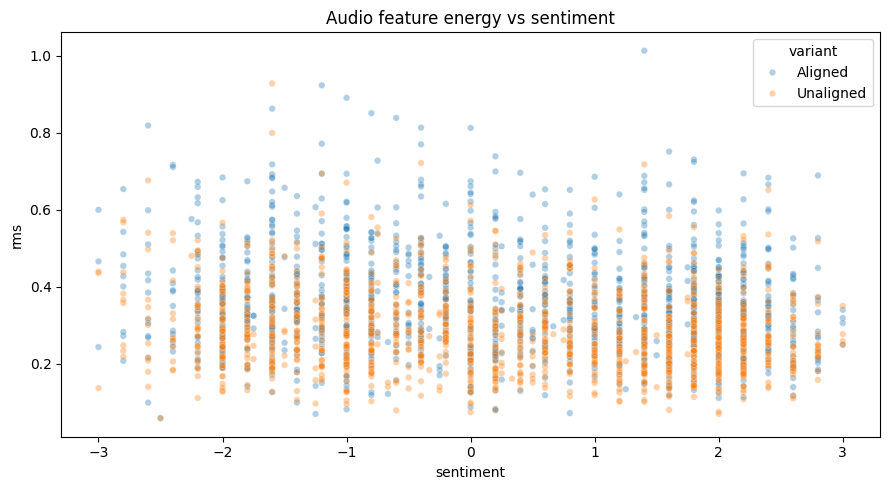

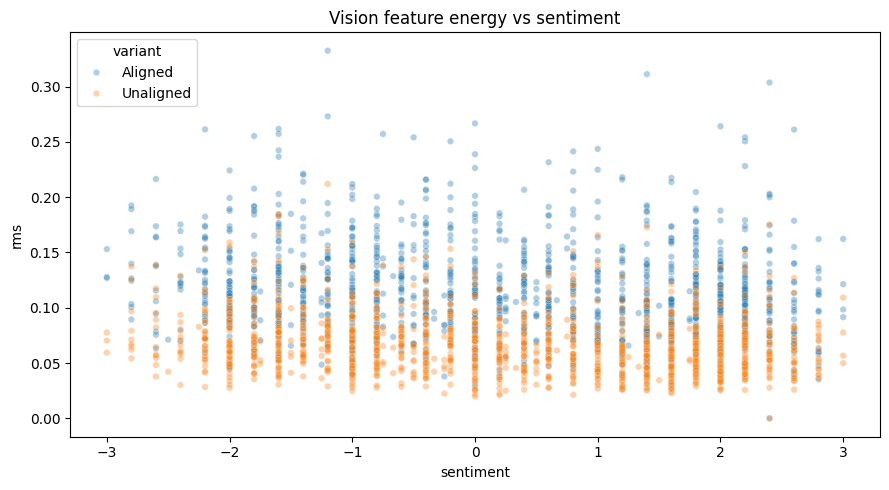

In [13]:
# ============================================================
# 13. SENTIMENT VS MODALITY ENERGY
# ============================================================
plot_rows = []

for variant, data in datasets.items():
    s = get_split(data, "train")
    if s is None:
        continue
    lk = find_label_key(s)
    if lk is None:
        continue
    y = np.asarray(s[lk], dtype=float).reshape(-1)

    for mod in MODALITIES:
        if mod not in s:
            continue
        a = np.asarray(s[mod], dtype=float)
        if a.ndim != 3 or len(y) != a.shape[0]:
            continue
        rms = np.sqrt(np.mean(a.reshape(a.shape[0], -1)**2, axis=1))
        n = min(len(y), 1500)
        idx = np.linspace(0, len(y)-1, n).astype(int)
        tmp = pd.DataFrame({"sentiment":y[idx], "rms":rms[idx],
                            "variant":variant, "modality":mod})
        plot_rows.append(tmp)

if plot_rows:
    sr = pd.concat(plot_rows, ignore_index=True)
    for mod in sr["modality"].unique():
        plt.figure(figsize=(9,5))
        sns.scatterplot(data=sr[sr.modality==mod], x="sentiment", y="rms",
                        hue="variant", alpha=.35, s=22)
        plt.title(f"{mod.title()} feature energy vs sentiment")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"07_{mod}_energy_vs_sentiment.png", dpi=180, bbox_inches="tight")
        plt.show()


,variant,modality,MAE,RMSE,Pearson_r
0,Aligned,text,1.2623,1.6082,0.4795
1,Aligned,audio,1.3944,1.6230,0.2032
2,Aligned,vision,1.4468,1.6980,0.1562
3,Unaligned,text,1.2623,1.6082,0.4795
4,Unaligned,audio,1.3862,1.6163,0.1997
5,Unaligned,vision,1.4482,1.6918,0.1532


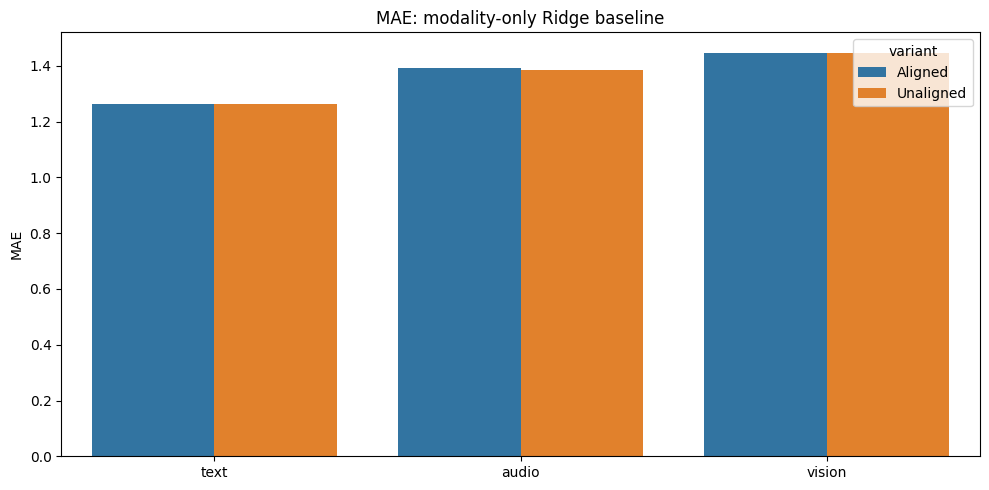

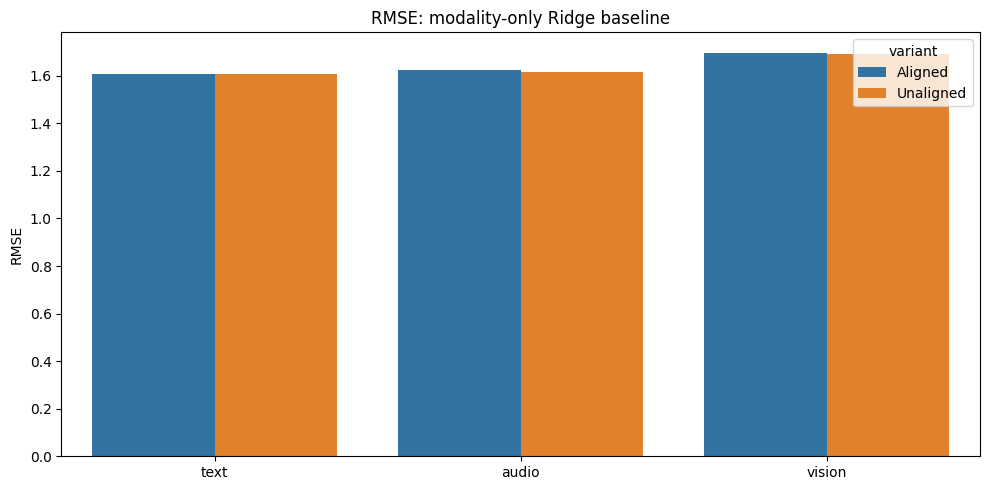

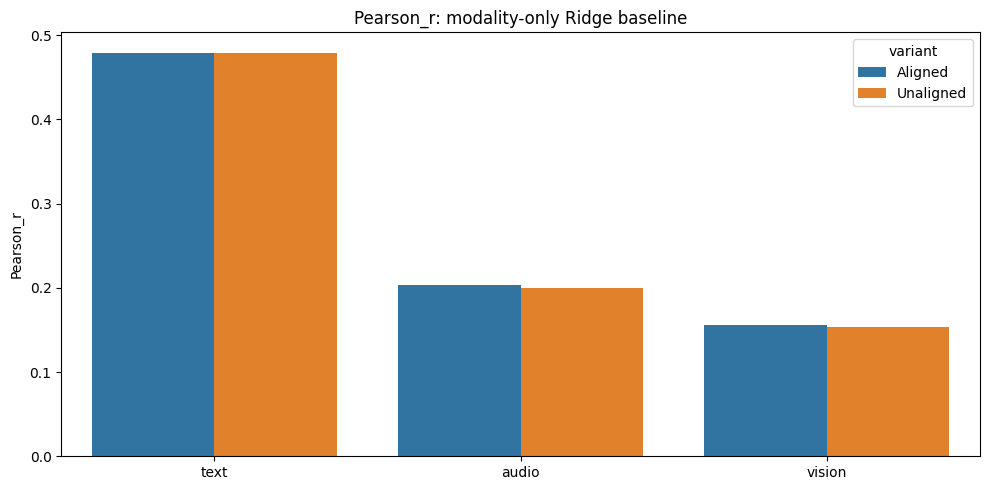

In [14]:
# ============================================================
# 14. SIMPLE MODALITY-ONLY BASELINES
# ============================================================
# Same model and preprocessing for both variants, so this is a fair
# representation-level comparison rather than a full model claim.

def sample_features(split, mod):
    a = np.asarray(split[mod], dtype=float)
    if a.ndim == 3:
        return np.nanmean(a, axis=1)
    if a.ndim == 2:
        return a
    return a.reshape(a.shape[0], -1)

baseline_rows = []

for variant, data in datasets.items():
    tr = get_split(data, "train")
    te = get_split(data, "test")
    if tr is None or te is None:
        continue
    lk_tr, lk_te = find_label_key(tr), find_label_key(te)
    if lk_tr is None or lk_te is None:
        continue

    ytr = np.asarray(tr[lk_tr], dtype=float).reshape(-1)
    yte = np.asarray(te[lk_te], dtype=float).reshape(-1)

    for mod in MODALITIES:
        if mod not in tr or mod not in te:
            continue
        Xtr = sample_features(tr, mod)
        Xte = sample_features(te, mod)

        ntr, nte = min(len(Xtr), len(ytr)), min(len(Xte), len(yte))
        Xtr, ytr2 = Xtr[:ntr], ytr[:ntr]
        Xte, yte2 = Xte[:nte], yte[:nte]

        scaler = StandardScaler()
        Xtr_s = scaler.fit_transform(Xtr)
        Xte_s = scaler.transform(Xte)

        model = Ridge(alpha=1.0)
        model.fit(Xtr_s, ytr2)
        pred = model.predict(Xte_s)

        baseline_rows.append({
            "variant":variant,
            "modality":mod,
            "MAE":mean_absolute_error(yte2,pred),
            "RMSE":mean_squared_error(yte2,pred)**0.5,
            "Pearson_r":pearsonr(yte2,pred)[0] if np.std(pred)>0 else np.nan
        })

baseline_df = pd.DataFrame(baseline_rows)

if not baseline_df.empty:
    display(baseline_df)
    baseline_df.to_csv(TABLE_DIR / "modality_only_ridge_baselines.csv", index=False)

    for metric in ["MAE","RMSE","Pearson_r"]:
        plt.figure(figsize=(10,5))
        sns.barplot(data=baseline_df, x="modality", y=metric, hue="variant")
        plt.title(f"{metric}: modality-only Ridge baseline")
        plt.xlabel("")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"08_baseline_{metric}.png", dpi=180, bbox_inches="tight")
        plt.show()


In [15]:
# ============================================================
# 15. MEANINGFUL OBSERVATION SUMMARY
# ============================================================
print("="*72)
print("MEANINGFUL OBSERVATIONS FROM THE EDA")
print("="*72)

if "labels_df" in globals() and not labels_df.empty:
    for v, g in labels_df.groupby("variant"):
        print(f"\n[{v}]")
        print(f"- Samples: {len(g)}")
        print(f"- Mean sentiment: {g.sentiment.mean():.3f}")
        print(f"- Std sentiment: {g.sentiment.std():.3f}")

if "seq_summary" in globals() and not seq_summary.empty:
    print("\n[Sequence structure]")
    display(seq_summary)
    print("Interpretation: large aligned/unaligned sequence-length differences indicate that synchronization/resampling changes the temporal representation.")

if "zero_df" in globals() and not zero_df.empty:
    print("\n[Zero/padding behaviour]")
    display(zero_df)
    print("Interpretation: high exact-zero rates indicate sparsity/padding-like structure and should be considered during modelling.")

if "corr_df" in globals() and not corr_df.empty:
    print("\n[Modality–sentiment association]")
    display(corr_df)
    print("Interpretation: larger maximum |Pearson r| means at least one sample-level feature has stronger linear association with sentiment; this is not causal evidence.")

if "baseline_df" in globals() and not baseline_df.empty:
    print("\n[Simple downstream test]")
    display(baseline_df)
    print("Interpretation: lower MAE/RMSE and higher Pearson r indicate the representation is more useful under the same simple Ridge baseline.")


MEANINGFUL OBSERVATIONS FROM THE EDA

[Aligned]
- Samples: 1284
- Mean sentiment: 0.234
- Std sentiment: 1.510

[Unaligned]
- Samples: 1284
- Mean sentiment: 0.234
- Std sentiment: 1.510

[Sequence structure]


,variant,modality,mean,median,min,max,std
0,Aligned,audio,50.0000,50.0000,50,50,0.0000
1,Aligned,text,50.0000,50.0000,50,50,0.0000
2,Aligned,vision,50.0000,50.0000,50,50,0.0000
3,Unaligned,audio,375.0000,375.0000,375,375,0.0000
4,Unaligned,text,50.0000,50.0000,50,50,0.0000
5,Unaligned,vision,500.0000,500.0000,500,500,0.0000


Interpretation: large aligned/unaligned sequence-length differences indicate that synchronization/resampling changes the temporal representation.

[Zero/padding behaviour]


,variant,modality,zero_timestep_percent
0,Aligned,text,0.0000
1,Aligned,audio,75.9268
2,Aligned,vision,76.0670
3,Unaligned,text,0.0000
4,Unaligned,audio,89.3778
5,Unaligned,vision,90.4763


Interpretation: high exact-zero rates indicate sparsity/padding-like structure and should be considered during modelling.

[Modality–sentiment association]


,variant,modality,max_abs_feature_corr,median_abs_feature_corr
0,Aligned,text,0.3588,0.0877
1,Aligned,audio,0.1305,0.0724
2,Aligned,vision,0.2082,0.0581
3,Unaligned,text,0.3588,0.0877
4,Unaligned,audio,0.1454,0.0749
5,Unaligned,vision,0.2042,0.0727


Interpretation: larger maximum |Pearson r| means at least one sample-level feature has stronger linear association with sentiment; this is not causal evidence.

[Simple downstream test]


,variant,modality,MAE,RMSE,Pearson_r
0,Aligned,text,1.2623,1.6082,0.4795
1,Aligned,audio,1.3944,1.6230,0.2032
2,Aligned,vision,1.4468,1.6980,0.1562
3,Unaligned,text,1.2623,1.6082,0.4795
4,Unaligned,audio,1.3862,1.6163,0.1997
5,Unaligned,vision,1.4482,1.6918,0.1532


Interpretation: lower MAE/RMSE and higher Pearson r indicate the representation is more useful under the same simple Ridge baseline.


In [16]:
# ============================================================
# 16. SAVE RUN INFORMATION
# ============================================================
run_info = {
    "dataset": "CMU-MOSI",
    "processed_folder": str(DATA_DIR),
    "aligned_file": str(ALIGNED_PATH) if ALIGNED_PATH else None,
    "unaligned_file": str(UNALIGNED_PATH) if UNALIGNED_PATH else None,
    "figures_folder": str(FIG_DIR),
    "tables_folder": str(TABLE_DIR),
}
pd.Series(run_info).to_json(TABLE_DIR / "eda_run_info.json", indent=2)

print("Figures saved to:", FIG_DIR)
print("Tables saved to :", TABLE_DIR)


Figures saved to: /content/drive/MyDrive/mplmm_final_deliverables/outputs/CMU-MOSI/figures
Tables saved to : /content/drive/MyDrive/mplmm_final_deliverables/outputs/CMU-MOSI/tables
